# Construct Validity: Team Rating vs Match Outcome

Tests whether the match-rating algorithm's output tracks genuine performance, using
match result as the one external criterion available that isn't itself a rating.
Five linked findings, each one answering a question raised by the previous result
rather than standing alone.

**Dataset:** 155 Valencia CF matches. `match_id <= 106` = calibration set (fed the
PCA weights / Bayesian smoothing means & stds). `match_id > 106` = held-out,
never touched calibration.

**Pre-registered (see config cell below):** one-tailed Spearman test (H1: ρ > 0),
α = 0.05, effect-size bands with 0.3-0.5 set as the expected "healthy" range
*before* any results were seen.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import json

# Define the project root
project_root = Path("..").resolve().parent

# Add the project root to sys.path so Jupyter can find your 'src' module
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Load data/valencia_cf_1/matches.json into a dataframe called matches_df
matches_path = project_root / "data" / "valencia_cf_1" / "matches.json"

In [2]:
RANDOM_SEED = 42

# Calibration set = match_id <= this value (these matches fed the PCA weights /
# Bayesian smoothing means & stds). Anything above this id is held-out and never
# touched calibration.
CALIBRATION_MAX_MATCH_ID = 106

# Spearman test parameters
ALPHA = 0.05
ALTERNATIVE = "greater"  # H1: rho > 0 (positive monotonic relationship between
                         # team-average rating and goal difference)
N_BOOTSTRAP_RESAMPLES = 5000

# Effect-size bands for |rho|, pre-registered before seeing results
EFFECT_SIZE_BANDS = {
    "negligible": (0.00, 0.10),
    "weak":       (0.10, 0.30),
    "moderate":   (0.30, 0.50),
    "strong":     (0.50, 1.01),  # padded past 1.0 so the top band is inclusive
}

def classify_effect_size(rho: float) -> str:
    """Label |rho| against the pre-registered effect-size bands."""
    abs_rho = abs(rho)
    return next(
        (
            label
            for label, (lo, hi) in EFFECT_SIZE_BANDS.items()
            if lo <= abs_rho < hi
        ),
        "strong",
    )

In [3]:
with open(matches_path, "r") as f:
    data = json.load(f)

players_df = pd.json_normalize(
    data,
    record_path='player_performances',
    meta=['id']
)

players_df = players_df.rename(columns={'id': 'match_id'})

cols = ['match_id'] + [col for col in players_df.columns if col != 'match_id']
players_df = players_df[cols]

In [4]:
team_df = pd.json_normalize(data)

is_valencia_home = team_df['data.home_team_name'] == "Valencia CF"

team_df['val_goals_for'] = np.where(is_valencia_home, team_df['data.home_score'], team_df['data.away_score'])
team_df['val_goals_against'] = np.where(is_valencia_home, team_df['data.away_score'], team_df['data.home_score'])

team_df['val_xg_for'] = np.where(is_valencia_home, team_df['data.home_stats.xg'], team_df['data.away_stats.xg'])
team_df['val_xg_against'] = np.where(is_valencia_home, team_df['data.away_stats.xg'], team_df['data.home_stats.xg'])

team_df['goal_difference'] = team_df['val_goals_for'] - team_df['val_goals_against']

final_columns = [
    'id', 
    'data.in_game_date', 
    'data.competition',
    'data.home_team_name', 
    'data.away_team_name',
    'val_goals_for', 
    'val_goals_against', 
    'goal_difference',
    'val_xg_for', 
    'val_xg_against'
]

team_df = team_df[final_columns].rename(columns={
    'id': 'match_id',
    'data.in_game_date': 'date',
    'data.competition': 'competition',
    'data.home_team_name': 'home_team',
    'data.away_team_name': 'away_team'
})

## Finding 1 — Team-Average Rating vs Goal Difference

First and simplest test: does Valencia's team-average match rating correlate with
goal difference? Aggregates to outfield-only and all-performances versions in
parallel as a robustness check on whether goalkeeper inclusion matters.

In [5]:
# All performances (GK + outfield) - the version originally used.
match_averages_df = players_df.groupby('match_id')['match_rating'].mean().reset_index()

match_averages_df = match_averages_df.rename(columns={'match_rating': 'avg_match_rating'})

In [6]:
# Outfield-only - robustness comparison against the all-performances version above.
# Goalkeeper ratings run through separate heuristics (06c), so it's worth checking
# whether including them changes the construct-validity result rather than assuming
# either way by default.
match_averages_outfield_df = (
    players_df[players_df['performance_type'] == 'Outfield']
    .groupby('match_id')['match_rating']
    .mean()
    .reset_index()
    .rename(columns={'match_rating': 'avg_match_rating'})
)

In [7]:
team_averages_df = pd.merge(
    match_averages_df,
    team_df[['match_id', 'goal_difference']], 
    on='match_id',
    how='inner'
)

team_averages_df = team_averages_df.rename(columns={'goal_difference': 'goal_diff'})

In [8]:
team_averages_outfield_df = pd.merge(
    match_averages_outfield_df,
    team_df[['match_id', 'goal_difference']],
    on='match_id',
    how='inner'
).rename(columns={'goal_difference': 'goal_diff'})

In [9]:
calibration_set = team_averages_df[team_averages_df['match_id'] <= CALIBRATION_MAX_MATCH_ID].copy()
validation_set = team_averages_df[team_averages_df['match_id'] > CALIBRATION_MAX_MATCH_ID].copy()

calibration_set_outfield = team_averages_outfield_df[team_averages_outfield_df['match_id'] <= CALIBRATION_MAX_MATCH_ID].copy()
validation_set_outfield = team_averages_outfield_df[team_averages_outfield_df['match_id'] > CALIBRATION_MAX_MATCH_ID].copy()

In [10]:
# 1. Wrapper function for the bootstrap statistic
def spearman_statistic(x, y):
    return stats.spearmanr(x, y)[0]

# 2. Helper function to compute stats for any given dataset split
def analyze_split(df, rating_col='avg_match_rating', gd_col='goal_diff'):
    ratings = df[rating_col].values
    gds = df[gd_col].values
    
    # Pre-registered one-tailed test: H1 is rho > 0, not rho != 0
    rho, p_val = stats.spearmanr(ratings, gds, alternative=ALTERNATIVE)
    
    # Bootstrap CI on rho
    boot_res = stats.bootstrap(
        data=(ratings, gds),
        statistic=spearman_statistic,
        paired=True,
        vectorized=False,
        n_resamples=N_BOOTSTRAP_RESAMPLES,
        method='percentile',
        random_state=RANDOM_SEED
    )
    
    return rho, p_val, boot_res.confidence_interval.low, boot_res.confidence_interval.high, boot_res.standard_error

# 3. Run on all four splits: all-performances vs outfield-only, validation vs calibration
val_rho, val_p, val_ci_l, val_ci_h, val_se = analyze_split(validation_set)
cal_rho, cal_p, cal_ci_l, cal_ci_h, cal_se = analyze_split(calibration_set)
val_of_rho, val_of_p, val_of_ci_l, val_of_ci_h, val_of_se = analyze_split(validation_set_outfield)
cal_of_rho, cal_of_p, cal_of_ci_l, cal_of_ci_h, cal_of_se = analyze_split(calibration_set_outfield)

def print_comparison(label, v_rho, v_p, v_ci_l, v_ci_h, v_se, c_rho, c_p, c_ci_l, c_ci_h, c_se):
    print(label)
    print(
        f"{'Metric':<25} | {f'Validation (id > {str(CALIBRATION_MAX_MATCH_ID)})':<25} | Calibration (id <= {CALIBRATION_MAX_MATCH_ID})"
    )
    print("-" * 85)
    print(f"{'Spearman rho (ρ)':<25} | {v_rho:<25.3f} | {c_rho:.3f}")
    print(f"{'p-value':<25} | {v_p:<25.4f} | {c_p:.4f}")
    print(f"{'95% CI':<25} | [{v_ci_l:.3f}, {v_ci_h:.3f}]{'':<10} | [{c_ci_l:.3f}, {c_ci_h:.3f}]")
    print(f"{'Standard Error':<25} | {v_se:<25.4f} | {c_se:.4f}")
    print(f"{'Effect size':<25} | {classify_effect_size(v_rho):<25} | {classify_effect_size(c_rho)}")
    print(
        f"{f'Significant (α={str(ALPHA)})':<25} | {str(v_p < ALPHA):<25} | {c_p < ALPHA}"
    )
    print()

print_comparison("ALL PERFORMANCES (GK + outfield)",
                  val_rho, val_p, val_ci_l, val_ci_h, val_se,
                  cal_rho, cal_p, cal_ci_l, cal_ci_h, cal_se)

print_comparison("OUTFIELD ONLY (GK excluded)",
                  val_of_rho, val_of_p, val_of_ci_l, val_of_ci_h, val_of_se,
                  cal_of_rho, cal_of_p, cal_of_ci_l, cal_of_ci_h, cal_of_se)

print(f"Δρ (all - outfield): validation = {val_rho - val_of_rho:+.3f}, calibration = {cal_rho - cal_of_rho:+.3f}")

ALL PERFORMANCES (GK + outfield)
Metric                    | Validation (id > 106)     | Calibration (id <= 106)
-------------------------------------------------------------------------------------
Spearman rho (ρ)          | 0.826                     | 0.830
p-value                   | 0.0000                    | 0.0000
95% CI                    | [0.670, 0.917]           | [0.747, 0.887]
Standard Error            | 0.0635                    | 0.0362
Effect size               | strong                    | strong
Significant (α=0.05)      | True                      | True

OUTFIELD ONLY (GK excluded)
Metric                    | Validation (id > 106)     | Calibration (id <= 106)
-------------------------------------------------------------------------------------
Spearman rho (ρ)          | 0.823                     | 0.842
p-value                   | 0.0000                    | 0.0000
95% CI                    | [0.668, 0.912]           | [0.763, 0.898]
Standard Error            | 0

**Result:** ρ ≈ 0.82–0.84 across all four cuts (all-performances/outfield-only ×
calibration/validation). GK inclusion makes no meaningful difference
(Δρ ≈ ±0.01) - outfield-only adopted as the version used from here on.

This is far outside the pre-registered 0.3–0.5 "healthy moderate" band - strong
enough to be worth interrogating rather than taking as a clean pass. Drives
everything in the rest of this notebook.

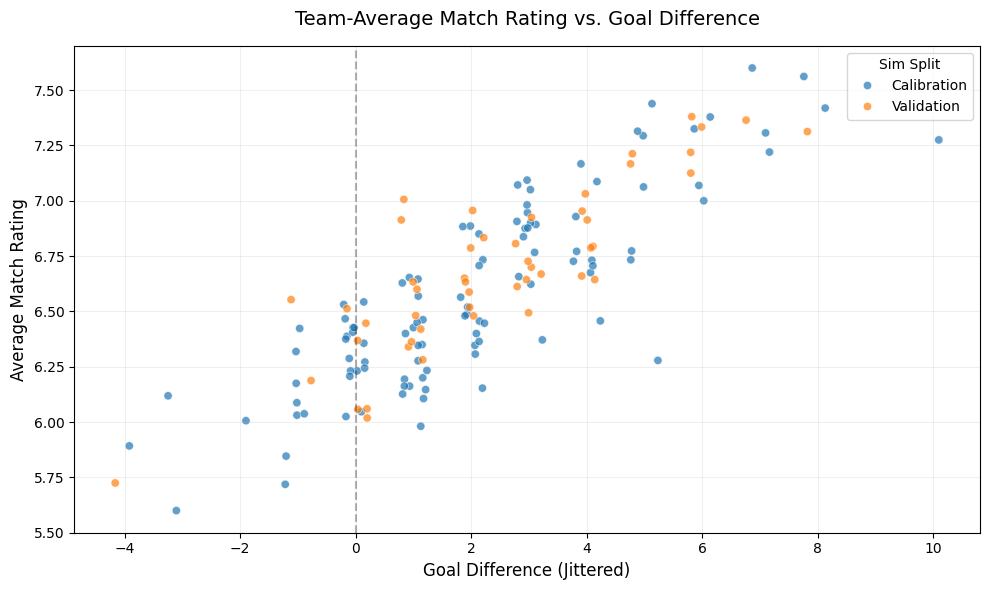

In [11]:
calibration_set['dataset'] = 'Calibration'
validation_set['dataset'] = 'Validation'
plot_df = pd.concat([calibration_set, validation_set])

# 2. Apply horizontal jitter to Goal Difference
rng = np.random.default_rng(RANDOM_SEED)  # instance-based, consistent with
                                           # cluster_bootstrap_spearman's approach -
                                           # doesn't mutate global numpy state
plot_df['gd_jittered'] = plot_df['goal_diff'] + rng.uniform(-0.25, 0.25, size=len(plot_df))

# 3. Build the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df, 
    x='gd_jittered', 
    y='avg_match_rating', 
    hue='dataset',
    palette={'Calibration': '#1f77b4', 'Validation': '#ff7f0e'}, # Clean blue/orange split
    alpha=0.7, # Transparency to handle any remaining overlap
    edgecolor='w',
    linewidth=0.5
)

# 4. Formatting
plt.title("Team-Average Match Rating vs. Goal Difference", fontsize=14, pad=15)
plt.xlabel("Goal Difference (Jittered)", fontsize=12)
plt.ylabel("Average Match Rating", fontsize=12)
plt.axvline(0, color='black', linestyle='--', alpha=0.3) # Reference line for draws
plt.grid(True, alpha=0.2)
plt.legend(title='Sim Split')

plt.tight_layout()
plt.show()

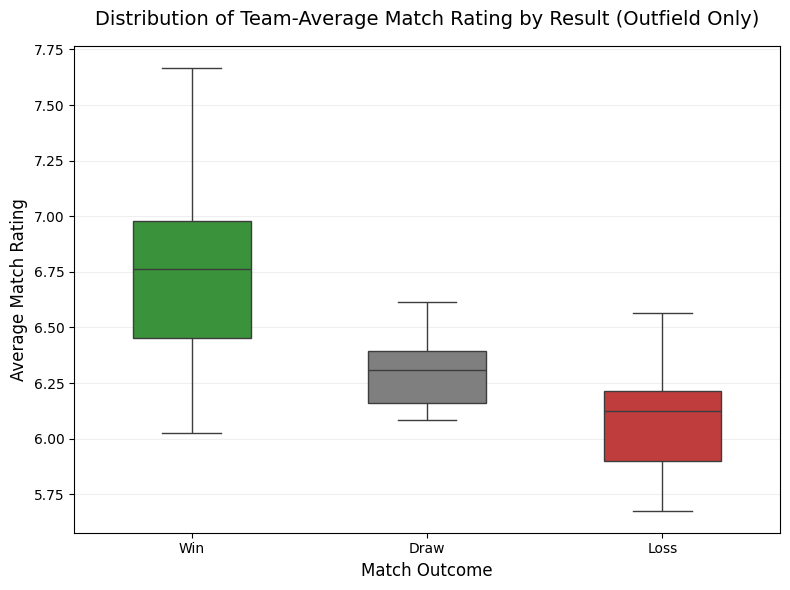

In [12]:
# 1. Derive W/D/L from Goal Difference (outfield-only, consistent with everything
# from cell 7 onward)
conditions = [
    (team_averages_outfield_df['goal_diff'] > 0),
    (team_averages_outfield_df['goal_diff'] == 0),
    (team_averages_outfield_df['goal_diff'] < 0)
]
choices = ['Win', 'Draw', 'Loss']

# Pass an explicit string default so NumPy maintains a uniform StrDType
team_averages_outfield_df['outcome'] = np.select(conditions, choices, default='Unknown')

# 2. Build the Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=team_averages_outfield_df,
    x='outcome',
    y='avg_match_rating',
    hue='outcome',
    order=['Win', 'Draw', 'Loss'], 
    palette={'Win': '#2ca02c', 'Draw': '#7f7f7f', 'Loss': '#d62728'},
    width=0.5,
    fliersize=4,
    legend=False
)

plt.title("Distribution of Team-Average Match Rating by Result (Outfield Only)", fontsize=14, pad=15)
plt.xlabel("Match Outcome", fontsize=12)
plt.ylabel("Average Match Rating", fontsize=12)
plt.grid(True, axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

## Finding 2 — Decorrelation Against xG Differential

The supremacy scalar (06a) is designed to neutralise rating's relationship with
**xG dominance** specifically, not goal difference. Re-running the same test
against xG differential checks rating against the actual variable the scalar
targets, rather than the proxy (GD) used in Finding 1.

In [13]:
team_df['xg_differential'] = team_df['val_xg_for'] - team_df['val_xg_against']

# How distinct is xG differential from actual goal difference? This bounds how much
# the comparison below can actually tell you - if the two are near-identical, a
# similar rho against both isn't informative either way.
gd_xg_rho, gd_xg_p = stats.spearmanr(team_df['goal_difference'], team_df['xg_differential'])
print(f"Spearman ρ(goal_difference, xg_differential) = {gd_xg_rho:.3f} (p = {gd_xg_p:.4f})")

Spearman ρ(goal_difference, xg_differential) = 0.668 (p = 0.0000)


In [14]:
team_averages_outfield_df = pd.merge(
    team_averages_outfield_df,
    team_df[['match_id', 'xg_differential']],
    on='match_id',
    how='inner'
)

calibration_set_outfield = team_averages_outfield_df[team_averages_outfield_df['match_id'] <= CALIBRATION_MAX_MATCH_ID].copy()
validation_set_outfield = team_averages_outfield_df[team_averages_outfield_df['match_id'] > CALIBRATION_MAX_MATCH_ID].copy()

xg_val_rho, xg_val_p, xg_val_ci_l, xg_val_ci_h, xg_val_se = analyze_split(validation_set_outfield, gd_col='xg_differential')
xg_cal_rho, xg_cal_p, xg_cal_ci_l, xg_cal_ci_h, xg_cal_se = analyze_split(calibration_set_outfield, gd_col='xg_differential')

print_comparison("OUTFIELD ONLY vs xG DIFFERENTIAL",
                  xg_val_rho, xg_val_p, xg_val_ci_l, xg_val_ci_h, xg_val_se,
                  xg_cal_rho, xg_cal_p, xg_cal_ci_l, xg_cal_ci_h, xg_cal_se)

print(f"Δρ (GD - xG): validation = {val_of_rho - xg_val_rho:+.3f}, calibration = {cal_of_rho - xg_cal_rho:+.3f}")

OUTFIELD ONLY vs xG DIFFERENTIAL
Metric                    | Validation (id > 106)     | Calibration (id <= 106)
-------------------------------------------------------------------------------------
Spearman rho (ρ)          | 0.563                     | 0.684
p-value                   | 0.0000                    | 0.0000
95% CI                    | [0.313, 0.736]           | [0.548, 0.786]
Standard Error            | 0.1073                    | 0.0612
Effect size               | strong                    | strong
Significant (α=0.05)      | True                      | True

Δρ (GD - xG): validation = +0.261, calibration = +0.158


**Result:** ρ(GD, xG differential) = 0.668 - related but genuinely distinct
quantities, not proxies for each other. Rating vs xG differential comes in at
ρ ≈ 0.56–0.68 - weaker than vs GD (Δρ +0.16 to +0.26), but still classified
"strong" by the pre-registered bands. Some reduction, but team-average rating
remains substantially coupled to the exact thing the scalar is meant to
decorrelate from.

## Supremacy Scalar Ablation
Re-runs every performance through a counterfactual service with the supremacy scalar
disabled (gamma=0 equivalent), to isolate how much of the rating-vs-xG-differential
correlation is attributable to the scalar specifically, versus other channels
(goal/assist bonuses, raw-stat inflation under PCA weighting).

In [15]:
# ADJUST: this import path is a guess based on your README's src/services/ layout -
# point it at wherever MatchRatingsService actually lives in your repo.
from src.services.analytics.match_ratings_service import MatchRatingsService


class NoSupremacyMatchRatingsService(MatchRatingsService):
    """MatchRatingsService with the supremacy scalar neutralised.

    Counterfactual used to isolate how much of the rating-vs-xG-differential
    correlation is attributable to the supremacy scalar itself, versus other
    channels in the pipeline (goal/assist bonuses, raw-stat inflation under
    PCA weighting) that the scalar was never designed to touch.
    """

    def _calculate_match_supremacy_scalar(self, team_xg, xg_against):
        return 0.0

In [16]:
# ADJUST: paths below assume weights/means_stds JSON sit at project root - point
# these at wherever they actually live.
with open(project_root / "config" / "performance_weights.json", "r") as f:
    weights = json.load(f)

with open(project_root / "config" / "performance_means_stds.json", "r") as f:
    means_stds = json.load(f)

real_service = MatchRatingsService(weights, means_stds)
ablated_service = NoSupremacyMatchRatingsService(weights, means_stds)

In [17]:
records = []
for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        args = (perf, match_overview, half_length, "Valencia CF")
        if perf['performance_type'] == 'GK':
            real_r = real_service.calculate_gk_rating(*args)
            abl_r = ablated_service.calculate_gk_rating(*args)
        else:
            real_r = real_service.calculate_outfield_rating(*args)
            abl_r = ablated_service.calculate_outfield_rating(*args)
        records.append({
            'match_id': match['id'],
            'player_id': perf['player_id'],
            'performance_type': perf['performance_type'],
            'rating_real_regenerated': real_r,
            'rating_no_supremacy': abl_r,
        })

regen_df = pd.DataFrame(records)

In [18]:
# Sanity check: rating_real_regenerated should match the stored match_rating almost
# exactly, since this is the same service fed the same inputs. If it doesn't, the
# regeneration loop isn't reproducing production inputs correctly - fix this before
# trusting the no-supremacy numbers below.
sanity_check_df = pd.merge(
    players_df[['match_id', 'player_id', 'match_rating']],
    regen_df[['match_id', 'player_id', 'rating_real_regenerated']],
    on=['match_id', 'player_id'],
    how='inner'
)

sanity_check_df['diff'] = (sanity_check_df['match_rating'] - sanity_check_df['rating_real_regenerated']).abs()

print(f"Rows compared: {len(sanity_check_df)}")
print(f"Max |difference|: {sanity_check_df['diff'].max():.6f}")
print(f"Rows with |difference| > 1e-6: {(sanity_check_df['diff'] > 1e-6).sum()}")

sanity_check_df.sort_values('diff', ascending=False).head(10)

Rows compared: 2401
Max |difference|: 0.000000
Rows with |difference| > 1e-6: 0


,match_id,player_id,match_rating,rating_real_regenerated,diff
0,1,2,7.0,7.0,0.0
1,1,20,6.4,6.4,0.0
2,1,4,5.8,5.8,0.0
3,1,14,7.0,7.0,0.0
4,1,11,6.0,6.0,0.0
5,1,12,6.1,6.1,0.0
6,1,22,6.0,6.0,0.0
7,1,28,6.0,6.0,0.0
8,1,24,8.7,8.7,0.0
9,1,41,5.8,5.8,0.0


In [19]:
regen_outfield_df = regen_df[
    (regen_df['performance_type'] == 'Outfield') &
    (regen_df['rating_no_supremacy'].notna())
]

match_averages_no_supremacy_df = (
    regen_outfield_df
    .groupby('match_id')['rating_no_supremacy']
    .mean()
    .reset_index()
    .rename(columns={'rating_no_supremacy': 'avg_match_rating'})
)

team_averages_no_supremacy_df = pd.merge(
    match_averages_no_supremacy_df,
    team_df[['match_id', 'xg_differential']],
    on='match_id',
    how='inner'
)

calibration_set_no_supremacy = team_averages_no_supremacy_df[team_averages_no_supremacy_df['match_id'] <= CALIBRATION_MAX_MATCH_ID].copy()
validation_set_no_supremacy = team_averages_no_supremacy_df[team_averages_no_supremacy_df['match_id'] > CALIBRATION_MAX_MATCH_ID].copy()

In [20]:
noSup_val_rho, noSup_val_p, noSup_val_ci_l, noSup_val_ci_h, noSup_val_se = analyze_split(
    validation_set_no_supremacy, gd_col='xg_differential'
)
noSup_cal_rho, noSup_cal_p, noSup_cal_ci_l, noSup_cal_ci_h, noSup_cal_se = analyze_split(
    calibration_set_no_supremacy, gd_col='xg_differential'
)

print_comparison("NO-SUPREMACY RATING vs xG DIFFERENTIAL",
                  noSup_val_rho, noSup_val_p, noSup_val_ci_l, noSup_val_ci_h, noSup_val_se,
                  noSup_cal_rho, noSup_cal_p, noSup_cal_ci_l, noSup_cal_ci_h, noSup_cal_se)

print("Three-way comparison vs xG differential:")
print(f"  Real rating          - validation: {xg_val_rho:.3f} | calibration: {xg_cal_rho:.3f}")
print(f"  No-supremacy rating  - validation: {noSup_val_rho:.3f} | calibration: {noSup_cal_rho:.3f}")
print(f"  Δρ (no-supremacy - real): validation = {noSup_val_rho - xg_val_rho:+.3f}, calibration = {noSup_cal_rho - xg_cal_rho:+.3f}")
print()
print("Meaningfully positive Δρ -> the scalar is doing real decorrelation work.")
print("Δρ close to zero -> the scalar's contribution here is negligible; the residual")
print("correlation with xG is coming from elsewhere in the pipeline.")

NO-SUPREMACY RATING vs xG DIFFERENTIAL
Metric                    | Validation (id > 106)     | Calibration (id <= 106)
-------------------------------------------------------------------------------------
Spearman rho (ρ)          | 0.708                     | 0.777
p-value                   | 0.0000                    | 0.0000
95% CI                    | [0.517, 0.826]           | [0.671, 0.852]
Standard Error            | 0.0782                    | 0.0463
Effect size               | strong                    | strong
Significant (α=0.05)      | True                      | True

Three-way comparison vs xG differential:
  Real rating          - validation: 0.563 | calibration: 0.684
  No-supremacy rating  - validation: 0.708 | calibration: 0.777
  Δρ (no-supremacy - real): validation = +0.145, calibration = +0.093

Meaningfully positive Δρ -> the scalar is doing real decorrelation work.
Δρ close to zero -> the scalar's contribution here is negligible; the residual
correlation with xG 

**Result:** removing the scalar entirely increases the xG correlation in both
splits (real: 0.563/0.684 → no-supremacy: 0.708/0.777). Direction confirms the
scalar is doing real work. But even fully disabled, the correlation with xG
remains strong - most of rating's sensitivity to match dominance survives the
scalar's removal, meaning it's coming from elsewhere in the pipeline (raw-stat
inflation under PCA weighting, goal/assist bonuses), not from a broken
decorrelation mechanism.

### Is the ablation effect statistically real?

Two separate CIs aren't enough to claim the gap above is genuine rather than
noise - they don't account for both ρ values being computed from the same
matches. Paired bootstrap (resampling matches once, applying that resample to
both ρ calculations together) tests the *difference* directly.

In [21]:
paired_df = pd.merge(
    team_averages_outfield_df[['match_id', 'avg_match_rating', 'xg_differential']].rename(
        columns={'avg_match_rating': 'rating_real'}
    ),
    team_averages_no_supremacy_df[['match_id', 'avg_match_rating']].rename(
        columns={'avg_match_rating': 'rating_no_supremacy'}
    ),
    on='match_id',
    how='inner'
)

calibration_paired = paired_df[paired_df['match_id'] <= CALIBRATION_MAX_MATCH_ID].copy()
validation_paired = paired_df[paired_df['match_id'] > CALIBRATION_MAX_MATCH_ID].copy()

In [ ]:
def delta_rho_statistic(rating_real, rating_no_supremacy, xg_diff):
    rho_real = stats.spearmanr(rating_real, xg_diff)[0]
    rho_no_sup = stats.spearmanr(rating_no_supremacy, xg_diff)[0]
    return rho_no_sup - rho_real

def paired_bootstrap_delta(df):
    rating_real = df['rating_real'].values
    rating_no_sup = df['rating_no_supremacy'].values
    xg_diff = df['xg_differential'].values

    point_delta = delta_rho_statistic(rating_real, rating_no_sup, xg_diff)

    boot_res = stats.bootstrap(
        data=(rating_real, rating_no_sup, xg_diff),
        statistic=delta_rho_statistic,
        paired=True,
        vectorized=False,
        n_resamples=N_BOOTSTRAP_RESAMPLES,
        method='percentile',
        random_state=RANDOM_SEED
    )
    return point_delta, boot_res.confidence_interval.low, boot_res.confidence_interval.high, boot_res.standard_error

val_delta, val_d_ci_l, val_d_ci_h, val_d_se = paired_bootstrap_delta(validation_paired)
cal_delta, cal_d_ci_l, cal_d_ci_h, cal_d_se = paired_bootstrap_delta(calibration_paired)

print("Δρ (no-supremacy - real), paired bootstrap, 95% CI")
print(f"{'Validation':<15} | Δρ = {val_delta:+.3f} | CI [{val_d_ci_l:+.3f}, {val_d_ci_h:+.3f}] | SE {val_d_se:.4f} | excludes 0: {val_d_ci_l > 0}")
print(f"{'Calibration':<15} | Δρ = {cal_delta:+.3f} | CI [{cal_d_ci_l:+.3f}, {cal_d_ci_h:+.3f}] | SE {cal_d_se:.4f} | excludes 0: {cal_d_ci_l > 0}")

Δρ (no-supremacy - real), paired bootstrap, 95% CI
Validation      | Δρ = +0.145 | CI [+0.061, +0.254] | SE 0.0498 | excludes 0: True
Calibration     | Δρ = +0.093 | CI [+0.058, +0.136] | SE 0.0201 | excludes 0: True


**Result:** Δρ = +0.145 (validation, CI [0.061, 0.254]) and +0.093 (calibration,
CI [0.058, 0.136]) - both CIs exclude zero. The scalar's decorrelation effect is
statistically real, not an artefact of comparing two point estimates by eye. It's
real, modest, and consistent across both splits - and still leaves a strong
residual correlation with xG dominance unaccounted for.

## Finding 3 — Player-Level vs Team-Average (Averaging Artefact Check)

Does ρ ≈ 0.83 hold at the grain the algorithm actually operates at - one player,
one match - or is it partly manufactured by averaging ~15 players' ratings
together? Averaging cancels individual noise and can produce a stronger
aggregate-level correlation than exists at the individual level
("ecological correlation") - this isn't a flaw, but it changes what the headline
number is actually evidence of.

In [23]:
outfield_players_df = players_df[players_df['performance_type'] == 'Outfield'].merge(
    team_df[['match_id', 'goal_difference']],
    on='match_id',
    how='inner'
)

n_before = len(outfield_players_df)
outfield_players_df = outfield_players_df.dropna(subset=['match_rating'])
n_after = len(outfield_players_df)
print(f"Dropped {n_before - n_after} rows with missing match_rating ({n_before} -> {n_after})")

calibration_players = outfield_players_df[outfield_players_df['match_id'] <= CALIBRATION_MAX_MATCH_ID]
validation_players = outfield_players_df[outfield_players_df['match_id'] > CALIBRATION_MAX_MATCH_ID]

Dropped 55 rows with missing match_rating (2246 -> 2191)


In [ ]:
def cluster_bootstrap_spearman(df, rating_col='match_rating', gd_col='goal_difference',
                                cluster_col='match_id', n_resamples=N_BOOTSTRAP_RESAMPLES,
                                seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)

    # Pre-split into per-match arrays once, so each resample is just array lookups.
    groups = {
        mid: (sub[rating_col].values, sub[gd_col].values)
        for mid, sub in df.groupby(cluster_col)
    }
    match_ids = np.array(list(groups.keys()))
    n_matches = len(match_ids)

    boot_rhos = np.empty(n_resamples)
    for i in range(n_resamples):
        sampled_ids = rng.choice(match_ids, size=n_matches, replace=True)
        ratings = np.concatenate([groups[mid][0] for mid in sampled_ids])
        gds = np.concatenate([groups[mid][1] for mid in sampled_ids])
        boot_rhos[i] = stats.spearmanr(ratings, gds)[0]

    point_rho = stats.spearmanr(df[rating_col], df[gd_col])[0]
    ci_low, ci_high = np.percentile(boot_rhos, [2.5, 97.5])
    return point_rho, ci_low, ci_high, boot_rhos.std()


val_p_rho, val_p_ci_l, val_p_ci_h, val_p_se = cluster_bootstrap_spearman(validation_players)
cal_p_rho, cal_p_ci_l, cal_p_ci_h, cal_p_se = cluster_bootstrap_spearman(calibration_players)

print("Player-level ρ(match_rating, goal_difference), cluster bootstrap by match_id")
print(f"{'Validation':<15} | ρ = {val_p_rho:.3f} | CI [{val_p_ci_l:.3f}, {val_p_ci_h:.3f}] | SE {val_p_se:.4f} | n_matches={validation_players['match_id'].nunique()}, n_players={len(validation_players)}")
print(f"{'Calibration':<15} | ρ = {cal_p_rho:.3f} | CI [{cal_p_ci_l:.3f}, {cal_p_ci_h:.3f}] | SE {cal_p_se:.4f} | n_matches={calibration_players['match_id'].nunique()}, n_players={len(calibration_players)}")
print()
print("Compared to team-average rating:")
print(f"{'Validation':<15} | team-level ρ = {val_of_rho:.3f}")
print(f"{'Calibration':<15} | team-level ρ = {cal_of_rho:.3f}")
print()
print(f"Gap (team - player): validation = {val_of_rho - val_p_rho:+.3f}, calibration = {cal_of_rho - cal_p_rho:+.3f}")

Player-level ρ(match_rating, goal_difference), cluster bootstrap by match_id
Validation      | ρ = 0.257 | CI [0.163, 0.338] | SE 0.0439 | n_matches=49, n_players=711
Calibration     | ρ = 0.296 | CI [0.241, 0.346] | SE 0.0269 | n_matches=106, n_players=1480

Compared to team-average rating:
Validation      | team-level ρ = 0.823
Calibration     | team-level ρ = 0.842

Gap (team - player): validation = +0.567, calibration = +0.546


**Result:** player-level ρ ≈ 0.26–0.30 vs team-level ρ ≈ 0.82–0.84 - a gap of
+0.55 to +0.57. Most of the strength in Finding 1 is averaging, not tight
individual-level coupling. Individual ratings track GD only moderately -
arguably closer to where the *team-level* result was originally expected to
land (the pre-registered 0.3–0.5 band), just measured at the wrong grain the
first time.

## Finding 4 — Position-Group Breakdown

Pooling all outfield positions together for the player-level test may itself be
hiding structure - an attacker's rating responds to goals scored very
differently than a centre-back's does. Splitting by the same position-philosophy
groups already used for weight calibration (ST/Winger/CM/CDM/CB/Fullback) tests
whether the pooled 0.26–0.30 is a genuine average or a blend of very different
position-level relationships.

In [25]:
# Position-group mapping, matching the philosophy groups already used for weight
# calibration (cdm/fullback/cb/st/cm/winger/unknown_pos). Your example data only
# shows CB, CDM, CM, LB, LW, RB, RW, ST - if the full dataset has CAM, LM, RM etc.,
# add them here before trusting the 'Unknown' bucket's numbers.
POSITION_GROUP_MAP = {
    'ST': 'ST',
    'LW': 'Winger', 'RW': 'Winger',
    'CM': 'CM',
    'CDM': 'CDM',
    'CB': 'CB',
    'LB': 'Fullback', 'RB': 'Fullback',
}

# First listed position as primary - a simplification for this descriptive split,
# not the actual multi-position blending logic the service itself uses.
outfield_players_df['primary_position'] = outfield_players_df['positions_played'].apply(
    lambda pos: pos[0] if pos else None
)
outfield_players_df['position_group'] = (
    outfield_players_df['primary_position'].map(POSITION_GROUP_MAP).fillna('Unknown')
)

print(outfield_players_df['position_group'].value_counts())

position_group
Winger      452
CM          449
CB          428
Fullback    405
ST          244
CDM         211
Unknown       2
Name: count, dtype: int64


In [26]:
# Rebuilt here rather than reused from cell 23 - filtering creates a snapshot at
# that point in time, and cell 23's versions predate the position_group column
# added in cell 25. This rebuild is what actually picks that column up.
calibration_players = outfield_players_df[outfield_players_df['match_id'] <= CALIBRATION_MAX_MATCH_ID]
validation_players = outfield_players_df[outfield_players_df['match_id'] > CALIBRATION_MAX_MATCH_ID]

position_groups = [g for g in calibration_players['position_group'].unique() if g != 'Unknown']

print("Player-level ρ(match_rating, goal_difference) by position group, cluster bootstrap by match_id")
print(f"{'Group':<10} | {'Calibration ρ':<13} | {'Cal CI':<20} | n  || {'Validation ρ':<13} | {'Val CI':<20} | n")
print("-" * 110)

for group in sorted(position_groups):
    cal_sub = calibration_players[calibration_players['position_group'] == group]
    val_sub = validation_players[validation_players['position_group'] == group]

    cal_rho, cal_ci_l, cal_ci_h, _ = cluster_bootstrap_spearman(cal_sub)
    val_rho, val_ci_l, val_ci_h, _ = cluster_bootstrap_spearman(val_sub)

    print(f"{group:<10} | {cal_rho:<13.3f} | [{cal_ci_l:.3f}, {cal_ci_h:.3f}]{'':<6} | {len(cal_sub):<3} || {val_rho:<13.3f} | [{val_ci_l:.3f}, {val_ci_h:.3f}]{'':<6} | {len(val_sub)}")

Player-level ρ(match_rating, goal_difference) by position group, cluster bootstrap by match_id
Group      | Calibration ρ | Cal CI               | n  || Validation ρ  | Val CI               | n
--------------------------------------------------------------------------------------------------------------
CB         | 0.226         | [0.096, 0.353]       | 287 || 0.149         | [-0.038, 0.323]       | 141
CDM        | 0.314         | [0.166, 0.452]       | 148 || 0.180         | [-0.051, 0.399]       | 63
CM         | 0.380         | [0.280, 0.471]       | 300 || 0.412         | [0.254, 0.548]       | 149
Fullback   | 0.249         | [0.129, 0.354]       | 273 || 0.104         | [-0.058, 0.253]       | 132
ST         | 0.316         | [0.168, 0.461]       | 165 || 0.223         | [0.039, 0.394]       | 79
Winger     | 0.325         | [0.207, 0.431]       | 305 || 0.348         | [0.151, 0.522]       | 147


**Result:** real heterogeneity. CM (0.38/0.41) and Winger (0.33/0.35) hold up
consistently across both splits. CB (0.23/0.15) and Fullback (0.25/0.10) are
weaker and validation crosses zero for both - though this may be testing
defensive positions against the wrong half of the scoreline (see below). CDM
sits in between either way.

### Position-Appropriate Criteria

GD conflates two different constructs depending on position. Attacking output
(ST/Winger/CM) should track `goals_for`. Defensive output (CB/Fullback) should
track `goals_against`, inverted so positive ρ still means "better rating, better
defensive outcome." CDM tested against both, since the role straddles attack and
defence and the result above didn't clearly favour either side.

In [27]:
# Guarded - safe to re-run without first re-running cell 23. Without this check,
# running this cell twice in the same session silently produces val_goals_for_x /
# val_goals_for_y suffixed duplicate columns instead of erroring.
if 'val_goals_for' not in outfield_players_df.columns:
    outfield_players_df = outfield_players_df.merge(
        team_df[['match_id', 'val_goals_for', 'val_goals_against']],
        on='match_id',
        how='left'
    )

# Inverted so the "good" direction is consistent with the attacking criterion -
# a positive rho here means better rating tracks with fewer goals conceded.
outfield_players_df['defensive_value'] = -outfield_players_df['val_goals_against']

calibration_players = outfield_players_df[outfield_players_df['match_id'] <= CALIBRATION_MAX_MATCH_ID]
validation_players = outfield_players_df[outfield_players_df['match_id'] > CALIBRATION_MAX_MATCH_ID]

In [28]:
CRITERION_MAP = {
    'ST': 'val_goals_for',
    'Winger': 'val_goals_for',
    'CM': 'val_goals_for',
    'CB': 'defensive_value',
    'Fullback': 'defensive_value',
    # CDM excluded here - tested separately against both below, since its role
    # straddles attack/defence and the earlier result didn't clearly favour either.
}

print("Player-level ρ(match_rating, position-appropriate criterion), cluster bootstrap by match_id")
print(f"{'Group':<10} | {'Criterion':<16} | {'Calibration ρ':<13} | {'Cal CI':<20} | n  || {'Validation ρ':<13} | {'Val CI':<20} | n")
print("-" * 130)

for group, criterion in CRITERION_MAP.items():
    cal_sub = calibration_players[calibration_players['position_group'] == group]
    val_sub = validation_players[validation_players['position_group'] == group]

    cal_rho, cal_ci_l, cal_ci_h, _ = cluster_bootstrap_spearman(cal_sub, gd_col=criterion)
    val_rho, val_ci_l, val_ci_h, _ = cluster_bootstrap_spearman(val_sub, gd_col=criterion)

    print(f"{group:<10} | {criterion:<16} | {cal_rho:<13.3f} | [{cal_ci_l:.3f}, {cal_ci_h:.3f}]{'':<6} | {len(cal_sub):<3} || {val_rho:<13.3f} | [{val_ci_l:.3f}, {val_ci_h:.3f}]{'':<6} | {len(val_sub)}")

# CDM against both - let the data show which one it actually tracks, rather than guessing.
for criterion in ['val_goals_for', 'defensive_value']:
    cal_sub = calibration_players[calibration_players['position_group'] == 'CDM']
    val_sub = validation_players[validation_players['position_group'] == 'CDM']

    cal_rho, cal_ci_l, cal_ci_h, _ = cluster_bootstrap_spearman(cal_sub, gd_col=criterion)
    val_rho, val_ci_l, val_ci_h, _ = cluster_bootstrap_spearman(val_sub, gd_col=criterion)

    print(f"{'CDM':<10} | {criterion:<16} | {cal_rho:<13.3f} | [{cal_ci_l:.3f}, {cal_ci_h:.3f}]{'':<6} | {len(cal_sub):<3} || {val_rho:<13.3f} | [{val_ci_l:.3f}, {val_ci_h:.3f}]{'':<6} | {len(val_sub)}")

Player-level ρ(match_rating, position-appropriate criterion), cluster bootstrap by match_id
Group      | Criterion        | Calibration ρ | Cal CI               | n  || Validation ρ  | Val CI               | n
----------------------------------------------------------------------------------------------------------------------------------
ST         | val_goals_for    | 0.406         | [0.265, 0.541]       | 165 || 0.293         | [0.114, 0.452]       | 79
Winger     | val_goals_for    | 0.343         | [0.229, 0.447]       | 305 || 0.404         | [0.217, 0.557]       | 147
CM         | val_goals_for    | 0.403         | [0.307, 0.487]       | 300 || 0.401         | [0.242, 0.539]       | 149
CB         | defensive_value  | 0.432         | [0.335, 0.519]       | 287 || 0.300         | [0.146, 0.447]       | 141
Fullback   | defensive_value  | 0.453         | [0.362, 0.535]       | 273 || 0.330         | [0.189, 0.462]       | 132
CDM        | val_goals_for    | 0.337         | [0.181,

**Result:** CB and Fullback both strengthen substantially against the
position-appropriate criterion (CB: 0.23/0.15 → 0.43/0.30; Fullback: 0.25/0.10 →
0.45/0.33) - validation now clears zero cleanly for both, the highest
correlations in the table. Confirms the earlier weak/unstable defensive result
was about testing against the wrong half of the scoreline, not a validity gap.
CDM doesn't improve against `defensive_value` (0.18/0.14, validation crosses
zero) and isn't clearly better against `val_goals_for` either - genuinely
unresolved, not just under-tested. A regression against both goals_for and
goals_against jointly (cluster-robust SEs) was scoped as a next step but not run.

## Caveats Not Yet Resolved

- **Multiple comparisons:** ~18 individual significance checks run across the
  position/criterion battery (Findings 4-5), none formally corrected. Effect
  sizes are mostly large enough that this likely doesn't change the qualitative
  picture, but CDM's borderline status in particular should be read with this
  in mind.
- **Significance convention shift:** Finding 1-2 use the pre-registered
  one-tailed test against α=0.05. Findings 3-5 (`cluster_bootstrap_spearman`)
  only report whether the 95% CI excludes zero - a different, roughly two-tailed
  standard, applied without re-stating it as a deliberate change.
- **Ablation residual confound:** removing the supremacy scalar isolates *that
  mechanism* specifically, but doesn't separate "well-calibrated defensive
  merit" from "defenders on dominant teams still get inflated raw stats under
  PCA weighting via a different channel than the scalar."
- **Calibration boundary:** see note at the top of this notebook - 106/49 needs
  confirming against what was actually used in calibration.

Full synthesis and whitepaper write-up (06a language, Appendix A positional
notes) to follow separately.